To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [ ]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install or uv pip install
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [ ]:
#@title Colab Extra Install { display-mode: "form" }
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
    except: _numpy = "numpy"; _pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    _vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
    !uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} torchvision bitsandbytes xformers unsloth
    !uv pip install -qqq {_triton}
    !uv pip install -qqq --no-deps --upgrade "torchao>=0.16.0"
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

### Unsloth

Load up `Gemma 3 1B Instruct`, and set parameters

In [ ]:
from unsloth import FastModel
import torch
max_seq_length = 1024

fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",

    # Other popular models!
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/Llama-3.3-70B",
    "unsloth/mistral-7b-instruct-v0.3",
    "unsloth/Phi-4",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-1b-it",
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = False,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "YOUR_HF_TOKEN", # HF Token for gated models
)

==((====))==  Unsloth 2026.6.9: Fast Gemma3 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


In [ ]:
model.config

Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float16",
  "eos_token_id": 106,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 1152,
  "initializer_range": 0.02,
  "intermediate_size": 6912,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attent

We now add LoRA adapters so we only need to update a small amount of parameters!

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # Should leave on always!

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

### Data Prep
<a name="Data"></a>

We're using OpenAI's famous GSM8K dataset!

In [ ]:
!unzip /content/dataset_coa_basic_Slides.zip

Archive:  /content/dataset_coa_basic_Slides.zip
   creating: dataset_coa_basic_Slides/
  inflating: dataset_coa_basic_Slides/all_lectures.csv  
  inflating: dataset_coa_basic_Slides/all_lectures_analysis.csv  
   creating: dataset_coa_basic_Slides/per_lecture/
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_1.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_10.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_11.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_12.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_13.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_14.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_15.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_16.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_17.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_18.csv  
  inflating: dataset_coa_basic_Slides/per_lecture/lecture_19.csv  
  i

In [ ]:
import pandas as pd
df=pd.read_csv("/content/dataset_coa_basic_Slides/all_lectures.csv")


In [ ]:
df.head()

,lecture_number,slide_number,image_path,ocr_text,transcript
0,1,1,C:\Users\Sonali\Downloads\coa_basic_Slides\sli...,<title>Layered Computer Design</title>\n<diagr...,If you see a computer design in a layered view...
1,1,2,C:\Users\Sonali\Downloads\coa_basic_Slides\sli...,<title>Defining Computer Architecture</title>\...,The computer architecture defines mainly the f...
2,1,3,C:\Users\Sonali\Downloads\coa_basic_Slides\sli...,<title>Flynn's Classification of Computer Arch...,The Flynn’s classification of computer archite...
3,1,4,C:\Users\Sonali\Downloads\coa_basic_Slides\sli...,<title>Course Objectives</title>\n<bullet>Unde...,Having defined the computer architecture and d...
4,1,5,C:\Users\Sonali\Downloads\coa_basic_Slides\sli...,<title>Syllabus</title>\n<bullet>Instruction S...,This course is a twenty hour lecture course an...


In [ ]:
df.columns

Index(['lecture_number', 'slide_number', 'image_path', 'ocr_text',
       'transcript'],
      dtype='str')

In [ ]:
def convert_windows_path_to_colab_path(path_str):
    return path_str.replace(
        "C:\\Users\\Sonali\\Downloads\\coa_basic_Slides",
        "/content/dataset_coa_basic_Slides"
    ).replace("\\", "/")

df["image_path"] = df["image_path"].apply(convert_windows_path_to_colab_path)

In [ ]:
df["image_path"][0]

'/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0001.png'

/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0001.png


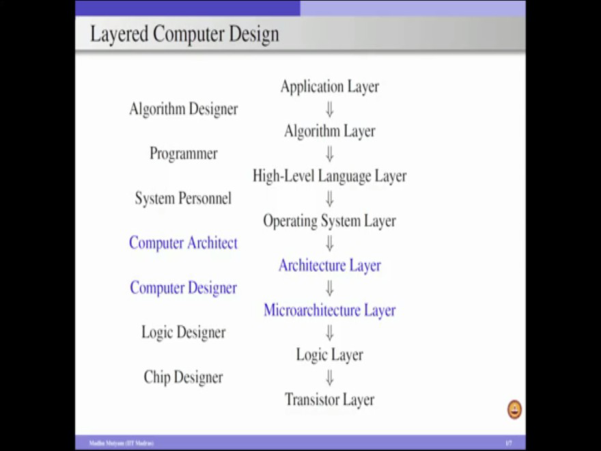

In [ ]:
from PIL import Image

sample_paths = df["image_path"][0]

print(sample_paths)

img = Image.open(sample_paths)
img

In [ ]:
lecture_df = (
    df.groupby("lecture_number")
      .agg({
          "image_path": list,
          "ocr_text": list,
          "transcript": list,
      })
      .reset_index()
)

In [ ]:
lecture_df["transcript_merged"] = (
    lecture_df["transcript"]
    .apply(lambda x: "\n".join([str(t) for t in x]))
)

In [ ]:
lecture_df["ocr_merged"] = (
    lecture_df["ocr_text"]
    .apply(lambda x: "\n".join([str(t) for t in x]))
)

In [ ]:
lengths = lecture_df["transcript_merged"].apply(
    lambda x: len(str(x).split())
)

print("Average:", lengths.mean())
print("Max:", lengths.max())

Average: 4832.272727272727
Max: 8171


In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(lecture_df)

In [ ]:
system_prompt = """
You are an experienced university professor.

Given all slides from a lecture,
generate a coherent educational narration.

Explain concepts naturally.
Maintain continuity between slides.
Avoid merely reading slide text.
"""

In [ ]:
def convert_sample(x):

    return {
        "image_paths": x["image_path"],
        "ocr_text": x["ocr_merged"],
        "instruction": system_prompt,
        "answer": x["transcript_merged"],
    }

In [ ]:
dataset = dataset.map(
    convert_sample,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

In [ ]:
dataset[0]

{'ocr_text': '<title>Layered Computer Design</title>\n<diagram>\nThis diagram illustrates the layered computer design, mapping personnel roles to corresponding layers.\nIt shows a hierarchy of layers with arrows indicating dependencies, starting from the application level down to transistors.\n\n**Personnel Column:**\nAlgorithm Designer\nProgrammer\nSystem Personnel\nComputer Architect\nComputer Designer\nLogic Designer\nChip Designer\n\n**Layer Column:**\nApplication Layer\nAlgorithm Layer\nHigh-Level Language Layer\nOperating System Layer\nArchitecture Layer\nMicroarchitecture Layer\nLogic Layer\nTransistor Layer\n\nThe roles "Computer Architect" and "Computer Designer", and the layers "Architecture Layer" and "Microarchitecture Layer" are highlighted.\n</diagram>\n<title>Defining Computer Architecture</title>\n<bullet>Functionality – Instruction set architecture</bullet>\n<bullet>Organization – Microarchitecture</bullet>\n<bullet>Efficient Implementation</bullet>\n<bullet>Personal m

In [ ]:
system_prompt = f"""
You are an experienced university professor.

Given all lecture slides, generate a coherent lecture narration.

Place the narration between:

{narration_start}
{narration_end}
"""

In [ ]:
dataset[0]

{'ocr_text': '<title>Layered Computer Design</title>\n<diagram>\nThis diagram illustrates the layered computer design, mapping personnel roles to corresponding layers.\nIt shows a hierarchy of layers with arrows indicating dependencies, starting from the application level down to transistors.\n\n**Personnel Column:**\nAlgorithm Designer\nProgrammer\nSystem Personnel\nComputer Architect\nComputer Designer\nLogic Designer\nChip Designer\n\n**Layer Column:**\nApplication Layer\nAlgorithm Layer\nHigh-Level Language Layer\nOperating System Layer\nArchitecture Layer\nMicroarchitecture Layer\nLogic Layer\nTransistor Layer\n\nThe roles "Computer Architect" and "Computer Designer", and the layers "Architecture Layer" and "Microarchitecture Layer" are highlighted.\n</diagram>\n<title>Defining Computer Architecture</title>\n<bullet>Functionality – Instruction set architecture</bullet>\n<bullet>Organization – Microarchitecture</bullet>\n<bullet>Efficient Implementation</bullet>\n<bullet>Personal m

In [ ]:
def build_prompt(x):

    return {
        "prompt": [
            {
                "role": "system",
                "content": system_prompt,
            },
            {
                "role": "user",
                "content":
                f"""
OCR CONTENT:

{x['ocr_text']}

Generate a lecture narration.
"""
            }
        ],
        "image_paths": x["image_paths"],
        "answer": x["answer"],
    }

In [ ]:
dataset = dataset.map(
    build_prompt,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

In [ ]:
dataset[0]

{'image_paths': ['/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0001.png',
  '/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0003.png',
  '/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0004.png',
  '/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0005.png',
  '/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0006.png',
  '/content/dataset_coa_basic_Slides/slides/lec1-2/lec1-2_p0007.png'],
 'answer': 'If you see a computer design in a layered view, there are several layers starting from the\napplication layer and all the way up to transistor layer. And each of these layers specifies set\nof operations and for example, if you consider application layer. So, talks about the type of\napplications that run on a computer. In general, a computer can run any application and so on,\nbut in reality when we design a computer, we design a computer for specific purposes. For\nexample, if we consider super computer. Our target applications for super comput

In [ ]:
from PIL import Image

sample = dataset[0]

images = [
    Image.open(path).convert("RGB")
    for path in sample["image_paths"]
]

In [ ]:
conversation = [
    {
        "role": "system",
        "content":
        """
You are an experienced university professor.

Generate a coherent lecture narration.

Place the narration between:

<NARRATION>
</NARRATION>
"""
    },
    {
        "role": "user",
        "content":
            [{"type":"image","image":img} for img in images]
            +
            [{
                "type":"text",
                "text":
                f"""
OCR CONTENT:

{sample["prompt"][1]["content"]}

Generate a lecture narration.
"""
            }]
    }
]

In [ ]:
FastModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForCausalLM(
      (model): Gemma3TextModel(
        (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma3DecoderLayer(
            (self_attn): Gemma3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1152, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              

In [ ]:
inputs = tokenizer.apply_chat_template(
    conversation,
    tokenize=True,
    return_tensors="pt",
    add_generation_prompt=True,
).to(model.device)

In [ ]:
print(type(inputs))

<class 'torch.Tensor'>


In [ ]:
outputs = model.generate(
    inputs,
    max_new_tokens=512,
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
print(inputs.shape)

torch.Size([1, 843])


In [ ]:
print(type(tokenizer))

<class 'transformers.models.gemma.tokenization_gemma_fast.GemmaTokenizerFast'>


In [ ]:
print(tokenizer)

GemmaTokenizerFast(name_or_path='unsloth/gemma-3-1b-it', vocab_size=262144, model_max_length=32768, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<end_of_turn>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'boi_token': '<start_of_image>', 'eoi_token': '<end_of_image>', 'image_token': '<image_soft_token>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<bos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	5: AddedToken("[multimodal]", rstrip=False, 

In [ ]:
print(type(model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

user

You are an experienced university professor.

Generate a coherent lecture narration.

Place the narration between:

<NARRATION>
</NARRATION>


OCR CONTENT:


OCR CONTENT:

<title>Layered Computer Design</title>
<diagram>
This diagram illustrates the layered computer design, mapping personnel roles to corresponding layers.
It shows a hierarchy of layers with arrows indicating dependencies, starting from the application level down to transistors.

**Personnel Column:**
Algorithm Designer
Programmer
System Personnel
Computer Architect
Computer Designer
Logic Designer
Chip Designer

**Layer Column:**
Application Layer
Algorithm Layer
High-Level Language Layer
Operating System Layer
Architecture Layer
Microarchitecture Layer
Logic Layer
Transistor Layer

The roles "Computer Architect" and "Computer Designer", and the layers "Architecture Layer" and "Microarchitecture Layer" are highlighted.
</diagram>
<title>Defining Computer Architecture</title>
<bullet>Functionality – Instruction se

In [ ]:
print(model.config)

Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float16",
  "eos_token_id": 106,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 1152,
  "initializer_range": 0.02,
  "intermediate_size": 6912,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attent

In [ ]:
from datasets import load_dataset
dataset = load_dataset("openai/gsm8k", "main", split = "train")
dataset

README.md:   0%|          | 0.00/7.94k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer'],
    num_rows: 7473
})

Let's look at the first row:

In [ ]:
dataset[0]["question"]

'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?'

In [ ]:
dataset[0]["answer"]

'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'

We notice all answers like about have a ####, so we extract it:

In [ ]:
def extract_hash_answer(text):
    if "####" not in text: return None
    return text.split("####")[1].strip()
extract_hash_answer(dataset[0]["answer"])

'72'

We now create a system prompt which can be customized. We add 4 extra symbols for working out or thinking / reasoning sections and a final answer:

In [ ]:
reasoning_start = "<start_working_out>"
reasoning_end   = "<end_working_out>"
solution_start = "<SOLUTION>"
solution_end = "</SOLUTION>"

system_prompt = \
f"""You are given a problem.
Think about the problem and provide your working out.
Place it between {reasoning_start} and {reasoning_end}.
Then, provide your solution between {solution_start}{solution_end}"""
system_prompt

'You are given a problem.\nThink about the problem and provide your working out.\nPlace it between <start_working_out> and <end_working_out>.\nThen, provide your solution between <SOLUTION></SOLUTION>'

Let's map the dataset! and see the first row:

In [ ]:
dataset = dataset.map(lambda x: {
    "prompt" : [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": x["question"]},
    ],
    "answer": extract_hash_answer(x["answer"]),
})
dataset[0]

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
 'answer': '72',
 'prompt': [{'content': 'You are given a problem.\nThink about the problem and provide your working out.\nPlace it between <start_working_out> and <end_working_out>.\nThen, provide your solution between <SOLUTION></SOLUTION>',
   'role': 'system'},
  {'content': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
   'role': 'user'}]}

We create a regex format to match the reasoning sections and answers:

In [ ]:
import re

match_format = re.compile(
    rf"^[\s]{{0,}}"\
    rf"{reasoning_start}.+?{reasoning_end}.*?"\
    rf"{solution_start}(.+?){solution_end}"\
    rf"[\s]{{0,}}$",
    flags = re.MULTILINE | re.DOTALL
)

We verify it works:

In [ ]:
match_format.search(
    "<start_working_out>Let me think!<end_working_out>"\
    "<SOLUTION>2</SOLUTION>",
)

<re.Match object; span=(0, 71), match='<start_working_out>Let me think!<end_working_out>>

We now want to create a reward function to match the format exactly - we reward it with 3 points if it succeeds:

In [ ]:
def match_format_exactly(completions, **kwargs):
    scores = []
    for completion in completions:
        score = 0
        response = completion[0]["content"]
        # Match if format is seen exactly!
        if match_format.search(response) is not None: score += 3.0
        scores.append(score)
    return scores

If it fails, we want to reward the model if it at least follows the format partially, by counting each symbol:

In [ ]:
def match_format_approximately(completions, **kwargs):
    scores = []
    for completion in completions:
        score = 0
        response = completion[0]["content"]
        # Count how many keywords are seen - we penalize if too many!
        # If we see 1, then plus some points!
        score += 0.5 if response.count(reasoning_start) == 1 else -0.5
        score += 0.5 if response.count(reasoning_end)   == 1 else -0.5
        score += 0.5 if response.count(solution_start)  == 1 else -0.5
        score += 0.5 if response.count(solution_end)    == 1 else -0.5
        scores.append(score)
    return scores

Finally, we want to extract the generated answer, and reward or penalize it! We also reward it based on how close the answer is to the true one via ratios:

In [ ]:
def check_answer(prompts, completions, answer, **kwargs):
    question = prompts[0][-1]["content"]
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [
        guess.group(1)
        if (guess := match_format.search(r)) is not None else None \
        for r in responses
    ]

    scores = []
    for guess, true_answer in zip(extracted_responses, answer):
        score = 0
        if guess is None:
            scores.append(0)
            continue
        # Correct answer gets 3 points!
        if guess == true_answer:
            score += 3.0
        # Match if spaces are seen
        elif guess.strip() == true_answer.strip():
            score += 1.5
        else:
            # We also reward it if the answer is close via ratios!
            # Ie if the answer is within some range, reward it!
            try:
                ratio = float(guess) / float(true_answer)
                if   ratio >= 0.9 and ratio <= 1.1: score += 0.5
                elif ratio >= 0.8 and ratio <= 1.2: score += 0.25
                else: score -= 1.0 # Penalize wrong answers
            except:
                score -= 0.5 # Penalize
        scores.append(score)
    return scores

Also sometimes it might not be 1 number as the answer, but like a sentence for example "The solution is $20" -> we extract 20.

In [ ]:
match_numbers = re.compile(
    rf"{solution_start}.*?([\d\.]{{1,}})",
    flags = re.MULTILINE | re.DOTALL
)
match_numbers.findall("<SOLUTION>  0.34  </SOLUTION>")

['0.34']

In [ ]:
def check_numbers(prompts, completions, answer, **kwargs):
    question = prompts[0][-1]["content"]
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [
        guess.group(1)
        if (guess := match_numbers.search(r)) is not None else None \
        for r in responses
    ]

    scores = []
    print('*'*20, f"Question:\n{question}", f"\nAnswer:\n{answer[0]}", f"\nResponse:\n{responses[0]}", f"\nExtracted:\n{extracted_responses[0]}")
    for guess, true_answer in zip(extracted_responses, answer):
        if guess is None:
            scores.append(0)
            continue
        # Convert to numbers
        try:
            true_answer = float(true_answer.strip())
            guess       = float(guess.strip())
            scores.append(1.5 if guess == true_answer else 0.0)
        except:
            scores.append(0)
            continue
    return scores

<a name="Train"></a>
### Train the model

Now set up GRPO Trainer and all configurations!

In [ ]:
max_prompt_length = 256

from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    learning_rate = 5e-6,
    adam_beta1 = 0.9,
    adam_beta2 = 0.99,
    weight_decay = 0.001,
    warmup_ratio = 0.1,
    lr_scheduler_type = "cosine",
    optim = "adamw_torch_fused",
    logging_steps = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 1, # Increase to 4 for smoother training
    num_generations = 4, # Decrease if out of memory
    max_prompt_length = max_prompt_length,
    max_completion_length = max_seq_length - max_prompt_length,
    # num_train_epochs = 1, # Set to 1 for a full training run
    max_steps = 50,
    save_steps = 50,
    max_grad_norm = 0.1,
    report_to = "none", # Can use Weights & Biases
    output_dir = "outputs",
)

Unsloth: We now expect `per_device_train_batch_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4


And let's run the trainer! If you scroll up, you'll see a table of rewards. The goal is to see the `reward` column increase!

You might have to wait 150 to 200 steps for any action. You'll probably get 0 reward for the first 100 steps. Please be patient!

| Step | Training Loss | reward    | reward_std | completion_length | kl       |
|------|---------------|-----------|------------|-------------------|----------|
| 1    | 0.000000      | 0.125000  | 0.000000   | 200.000000        | 0.000000 |
| 2    | 0.000000      | 0.072375  | 0.248112   | 200.000000        | 0.000000 |
| 3    | 0.000000      | -0.079000 | 0.163776   | 182.500000        | 0.000005 |

In [ ]:
trainer = GRPOTrainer(
    model = model,
    processing_class = tokenizer,
    reward_funcs = [
        match_format_exactly,
        match_format_approximately,
        check_answer,
        check_numbers,
    ],
    args = training_args,
    train_dataset = dataset,
)
trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,473 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 6,522,880/1,006,408,832 (0.65% trained)


******************** Question:
A concert ticket costs $40. Mr. Benson bought 12 tickets and received a 5% discount for every ticket bought that exceeds 10. How much did Mr. Benson pay in all? 
Answer:
476 
Response:
<start_working_out>
Let $C$ be the cost of a ticket, which is $C = 40$.
Let $N$ be the number of tickets Mr. Benson bought, which is $N = 12$.
The total cost of the tickets without discount is $N \times C = 12 \times 40 = 480$.
Mr. Benson received a 5% discount for every ticket bought that exceeds 10.
The number of tickets that exceed 10 is $12 - 10 = 2$.
The discount for each of these tickets is $5\%$ of $10 = 0.05 \times 10 = 0.5$.
The discount amount for the 2 tickets is $2 \times 0.5 = 1$.
The discounted price for each of the 2 tickets is $10 - 0.5 = 9.5$.
The total cost for the 2 tickets is $2 \times 9.5 = 19$.
The total cost of the tickets is the original cost minus the discount amount: $480 - 19 = 461$.
However, this is incorrect because we need to consider the discounts for the tickets that exceed 10.
Let $x$ be the number of tickets that exceed 10. We have $x = 12 - 10 = 2$.
The discount is 5% for each ticket that exceeds 10.
So the discounted price for each ticket is $40 \times (1 - 0.05) = 40 \times 0.95 = 38$.
The total cost for the 2 tickets is $2 \times 38 = 76$.
The total cost of the 12 tickets is $12 \times 40 = 480$.
The total discount is $2 \times 0.05 \times 12 = 0.1 \times 12 = 1.2$.
The total cost after discount is $480 - 1.2 = 478.8$.
However, we are given that Mr. Benson received a 5% discount for every ticket bought that exceeds 10.
So, we need to calculate the number of tickets that exceed 10.
Mr. Benson bought 12 tickets and received a 5% discount for every ticket bought that exceeds 10.
The number of tickets that exceed 10 is $12 - 10 = 2$.
The discount on each of these 2 tickets is $5\%$ of $10$, which is $0.05 \times 10 = 0.5$.
The discount amount for each of the 2 tickets is $0.5 \times 40 = 20$.
The discounted price for each of the 2 tickets is $40 - 20 = 20$.
The total cost for the 2 tickets is $2 \times 20 = 40$.
The total cost for the 12 tickets is $12 \times 40 = 480$.
The total discount is $2 \times 0.5 = 1$.
The total cost after discount is $480 - 1 = 479$.
But this is not correct.

Let $N = 12$. The cost per ticket is $40$.
The discount is 5% for 
Extracted:
None

Step,Training Loss,reward,reward_std,completion_length,kl,rewards / match_format_exactly,rewards / match_format_approximately,rewards / check_answer,rewards / check_numbers
1,0.000000,-1.000000,0.000000,758.250000,0.000000,0.000000,-1.000000,0.000000,0.000000
2,0.000000,-0.500000,0.577350,664.250000,0.000000,0.000000,-0.500000,0.000000,0.000000
3,0.000000,0.875000,1.181454,411.000000,0.000004,0.000000,0.500000,0.000000,0.375000
4,0.000000,1.500000,0.000000,269.250000,0.000003,0.000000,0.000000,0.000000,1.500000
5,0.000000,0.000000,0.000000,155.250000,0.000009,0.000000,0.000000,0.000000,0.000000
6,0.000000,-1.000000,0.000000,666.750000,0.000006,0.000000,-1.000000,0.000000,0.000000
7,0.000000,1.500000,0.000000,409.500000,0.000006,0.000000,0.000000,0.000000,1.500000
8,0.000000,-0.500000,0.577350,496.250000,0.000006,0.000000,-0.500000,0.000000,0.000000
9,0.000000,-0.750000,0.500000,634.500000,0.000008,0.000000,-0.750000,0.000000,0.000000
10,0.000000,-0.250000,0.500000,558.750000,0.000007,0.000000,-0.250000,0.000000,0.000000


Unsloth: Will smartly offload gradients to save VRAM!
******************** Question:
Jane is trying to decide whether to buy a house or a trailer. A house costs $480,000 and a trailer costs $120,000. Each loan will be paid in monthly installments over 20 years. How much more is the monthly payment on the house compared to the trailer? 
Answer:
1500 
Response:
<start_working_out>
We need to calculate the monthly payment on the house and the trailer.

House cost: $480,000
Loan amount: $480,000
Interest rate: We need to assume an interest rate for this problem. Let's assume an annual interest rate of 6% (this is a common rate).
Loan term: 20 years, so 20 * 12 = 240 months
We will use the loan payment formula: M = P [ i(1 + i)^n ] / [ (1 + i)^n – 1]
where M is the monthly payment, P is the loan amount, i is the monthly interest rate, and n is the number of months.

Monthly interest rate (i) = Annual interest rate / 12 = 0.06 / 12 = 0.005
Number of months (n) = 240

M = 480000 [ 0.005(1 + 0.005)^240 ] / [ (1 + 0.005)^240 – 1]
M = 480000 [ 0.005(1.005)^240 ] / [ (1.005)^240 – 1]
M = 480000 [ 0.005 * 3.310853] / [ 3.310853 – 1]
M = 480000 [ 0.016554265] / [2.310853]
M = 480000 * 0.00703658
M = $331.54

Trailer cost: $120,000
Loan amount: $120,000
Interest rate: We still assume an annual interest rate of 6% (this is a common rate).
Loan term: 20 years, so 20 * 12 = 240 months
We will use the loan payment formula: M = P [ i(1 + i)^n ] / [ (1 + i)^n – 1]
where M is the monthly payment, P is the loan amount, i is the monthly interest rate, and n is the number of months.

Monthly interest rate (i) = Annual interest rate / 12 = 0.06 / 12 = 0.005
Number of months (n) = 240

M = 120000 [ 0.005(1 + 0.005)^240 ] / [ (1 + 0.005)^240 – 1]
M = 120000 [ 0.005(1.005)^240 ] / [ (1.005)^240 – 1]
M = 120000 [ 0.005 * 3.310853 ] / [ 3.310853 – 1]
M = 120000 [ 0.016554265] / [2.310853]
M = 1200 
Extracted:
None
******************** Question:
Janet pays $40/hour for 3 hours per week of clarinet lessons and $28/hour for 5 hours a week of piano lessons. How much more does she spend on piano lessons than clarinet lessons in a year? 
Answer:
1040 
Response:
<start_working_out>
Let $C$ be the amount Janet spends on clarinet lessons per week, and $P$ be the amount Janet spends on piano lessons per week.
Janet pays $40/hour for 3 hours per week of clarinet lessons, so $C = 40 \times 3 = 120$.
Janet pays $28/hour for 5 hours a week of piano lessons, so $P = 28 \times 5 = 140$.
Janet's weekly spending on clarinet lessons is $120/week$, and her weekly spending on piano lessons is $140/week$.
There are 52 weeks in a year.
The amount she spends on clarinet lessons in a year is $120 \times 52 = 6240$.
The amount she spends on piano lessons in a year is $140 \times 52 = 7280$.
The difference between the amount she spends on piano lessons and clarinet lessons in a year is $7280 - 6240 = 1040$.

<SOLUTION>
The amount she spends on clarinet lessons in a year is $120 \times 52 = 6240$.
The amount she spends on piano lessons in a year is $140 \times 52 = 7280$.
The difference between the amount she spends on piano lessons and clarinet lessons in a year is $7280 - 6240 = 1040$.

Final Answer: The final answer is $\boxed{1040}$ 
Extracted:
120
******************** Question:
Sabrina is collecting herbs to make a poultice for her grandmother. She needs twice as many basil leaves as sage leaves and 5 fewer sage leaves than verbena leaves. If she needs 12 basil leaves, how many leaves total does she need? 
Answer:
29 
Response:
<start_working_out>
Let $b$ be the number of basil leaves, $s$ be the number of sage leaves, and $v$ be the number of verbena leaves.
We are given that Sabrina needs twice as many basil leaves as sage leaves, so $b = 2s$.
We are also given that she needs 5 fewer sage leaves than verbena leaves, so $s = v - 5$.
We are told that she needs 12 basil leaves, so $b = 12$.
We can use the equation $b = 2s$ to solve for $s$:
$12 = 2s$
$s = \frac{12}{2}$
$s = 6$
No

<a name="Inference"></a>
### Inference
Now let's try the model we just trained!

In [ ]:
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user",   "content": "What is the sqrt of 101?"},
]

text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize = False,
)
from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 64, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

<start_working_out>
The square root of 101 is approximately 10.0498756.
<SOLUTION>
10.0498756<end_of_turn>

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("gemma_3_lora")  # Local saving
tokenizer.save_pretrained("gemma_3_lora")
# model.push_to_hub("HF_ACCOUNT/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("HF_ACCOUNT/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving

('gemma-3/tokenizer_config.json',
 'gemma-3/special_tokens_map.json',
 'gemma-3/tokenizer.model',
 'gemma-3/added_tokens.json',
 'gemma-3/tokenizer.json')

### Saving to float16 for VLLM

We also support saving to `float16` directly for deployment! We save it in the folder `gemma-3-finetune`. Set `if False` to `if True` to let it run!

In [ ]:
if False: # Change to True to save finetune!
    model.save_pretrained_merged("gemma-3-finetune", tokenizer)

If you want to upload / push to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if False: # Change to True to upload finetune
    model.push_to_hub_merged(
        "HF_ACCOUNT/gemma-3-finetune", tokenizer,
        token = "YOUR_HF_TOKEN"
    )

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now for all models! For now, you can convert easily to `Q8_0, F16 or BF16` precision. `Q4_K_M` for 4bit will come later!

In [ ]:
if False: # Change to True to save to GGUF
    model.save_pretrained_gguf(
        "gemma_3_finetune",
        tokenizer,
        quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
    )

Likewise, if you want to instead push to GGUF to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if False: # Change to True to upload GGUF
    model.push_to_hub_gguf(
        "HF_ACCOUNT/gemma_3_finetune",
        tokenizer,
        quantization_method = "Q8_0", # Only Q8_0, BF16, F16 supported
        token = "YOUR_HF_TOKEN",
    )

Now, use the `gemma-3-finetune.gguf` file or `gemma-3-finetune-Q4_K_M.gguf` file in llama.cpp.

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).